# 01 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** entender la estructura del dataset Olist, identificar nulos, distribuciones y definir las variables objetivo:
- `dias_entrega` → regresión (¿cuántos días tardó?)
- `es_retraso` → clasificación (¿llegó tarde respecto a la fecha estimada?)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('../dataset')
OUT_DIR  = Path('../outputs/graficas')

## 1. Carga de datos

In [2]:
orders    = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

items     = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products  = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
geo       = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
payments  = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
cat_names = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print('Órdenes:   ', orders.shape)
print('Items:     ', items.shape)
print('Productos: ', products.shape)
print('Clientes:  ', customers.shape)
print('Vendedores:', sellers.shape)
print('Geoloc:    ', geo.shape)

Órdenes:    (99441, 8)
Items:      (112650, 7)
Productos:  (32951, 9)
Clientes:   (99441, 5)
Vendedores: (3095, 4)
Geoloc:     (1000163, 5)


## 2. Exploración de la tabla principal: órdenes

In [3]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


In [4]:
# Distribución de estados de órdenes
print(orders['order_status'].value_counts())
print(f"\nNulos en orders:\n{orders.isnull().sum()}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Nulos en orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [5]:
# Filtrar solo órdenes entregadas con fecha real de entrega
entregadas = orders[
    (orders['order_status'] == 'delivered') &
    orders['order_delivered_customer_date'].notna()
].copy()

print(f'Órdenes entregadas válidas: {len(entregadas):,} de {len(orders):,}')

Órdenes entregadas válidas: 96,470 de 99,441


## 3. Variables objetivo

In [6]:
# días de entrega = desde compra hasta recepción
entregadas['dias_entrega'] = (
    entregadas['order_delivered_customer_date'] - entregadas['order_purchase_timestamp']
).dt.days

# es_retraso = 1 si el paquete llegó después de la fecha estimada
entregadas['es_retraso'] = (
    entregadas['order_delivered_customer_date'] > entregadas['order_estimated_delivery_date']
).astype(int)

print(entregadas[['dias_entrega', 'es_retraso']].describe())
print(f"\nTasa de retrasos: {entregadas['es_retraso'].mean():.1%}")

       dias_entrega    es_retraso
count  96470.000000  96470.000000
mean      12.093604      0.081124
std        9.551380      0.273026
min        0.000000      0.000000
25%        6.000000      0.000000
50%       10.000000      0.000000
75%       15.000000      0.000000
max      209.000000      1.000000

Tasa de retrasos: 8.1%


In [7]:
# Eliminar valores negativos u outliers extremos
print(f"Días negativos: {(entregadas['dias_entrega'] < 0).sum()}")
print(f"Días > 60: {(entregadas['dias_entrega'] > 60).sum()}")

entregadas = entregadas[
    (entregadas['dias_entrega'] >= 0) &
    (entregadas['dias_entrega'] <= 60)
]
print(f'\nRegistros tras limpiar outliers: {len(entregadas):,}')

Días negativos: 0
Días > 60: 288

Registros tras limpiar outliers: 96,182


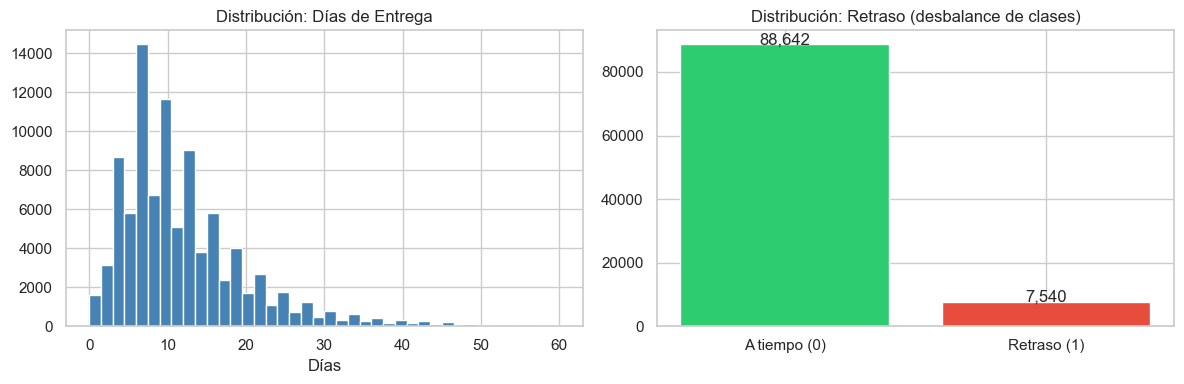

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(entregadas['dias_entrega'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución: Días de Entrega')
axes[0].set_xlabel('Días')

conteo = entregadas['es_retraso'].value_counts()
axes[1].bar(['A tiempo (0)', 'Retraso (1)'], conteo.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribución: Retraso (desbalance de clases)')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig(OUT_DIR / 'targets.png', dpi=100)
plt.show()

## 4. Distribución temporal

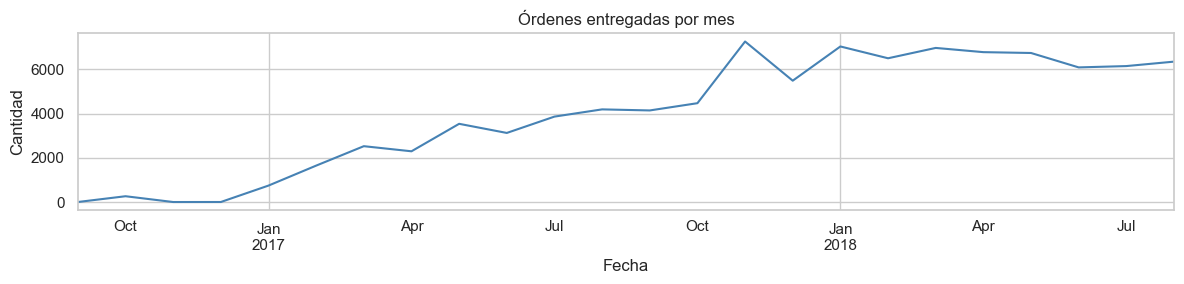

Rango temporal: 2016-09-15 → 2018-08-29


In [9]:
entregadas_sorted = entregadas.sort_values('order_purchase_timestamp')
mensual = entregadas_sorted.resample('ME', on='order_purchase_timestamp').size()

mensual.plot(figsize=(12, 3), title='Órdenes entregadas por mes', color='steelblue')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.savefig(OUT_DIR / 'ordenes_temporal.png', dpi=100)
plt.show()

print(f"Rango temporal: {entregadas['order_purchase_timestamp'].min().date()} → {entregadas['order_purchase_timestamp'].max().date()}")

## 5. Cobertura geográfica

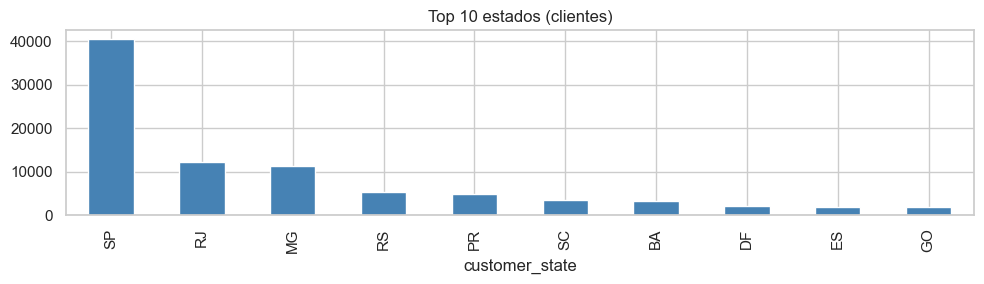

In [10]:
# Estados de clientes
df_estado = entregadas.merge(customers[['customer_id','customer_state']], on='customer_id')
top_estados = df_estado['customer_state'].value_counts().head(10)

top_estados.plot(kind='bar', figsize=(10, 3), color='steelblue', title='Top 10 estados (clientes)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'estados_clientes.png', dpi=100)
plt.show()

## 6. Resumen de nulos en tablas clave

In [11]:
tablas = {'products': products, 'items': items, 'sellers': sellers, 'customers': customers}
for nombre, df in tablas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        print(f'\n{nombre}:\n{nulos}')
    else:
        print(f'\n{nombre}: sin nulos')


products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

items: sin nulos

sellers: sin nulos

customers: sin nulos


## 7. Conclusiones del EDA

- El dataset tiene **~96K órdenes entregadas** válidas
- `dias_entrega` tiene distribución sesgada a la derecha (mediana ~12 días)
- `es_retraso` está **desbalanceado** (~8% retrasos) → usar `class_weight` en el modelo
- El rango temporal es 2016-2018 → split cronológico es crucial
- `products` tiene nulos en peso/dimensiones → se imputarán con mediana
- La geolocalización existe para todos los estados de Brasil